# Electron Drift Speed: Why the Bulb Turns On Quickly

This notebook is for an introductory electronics course. It uses simple models and plots to show:

1. **Drift speed of electrons is very slow** in typical wires.
2. **Random microscopic motion is fast**, but mostly cancels out.
3. **Electrical signals propagate quickly** through the circuit, so devices respond fast.

## Key Equation for Drift Speed

For a wire carrying current $I$, electron drift speed magnitude is:

$$v_d = \frac{I}{n q A}$$

Where:
- $n$: free electron density (for copper, about $8.5\times10^{28}\,\mathrm{m^{-3}}$)
- $q$: electron charge magnitude ($1.602\times10^{-19}\,\mathrm{C}$)
- $A$: wire cross-sectional area

So increasing current increases drift speed, while thicker wires decrease drift speed.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(7)

In [2]:
# Physical constants for copper wire examples
q = 1.602e-19            # Coulomb
n_cu = 8.5e28            # electrons / m^3

def drift_speed(I_amp, diameter_mm, n=n_cu):
    """Return electron drift speed magnitude in m/s."""
    radius_m = (diameter_mm * 1e-3) / 2
    area_m2 = np.pi * radius_m**2
    return I_amp / (n * q * area_m2)

examples = [
    (0.1, 0.5),
    (1.0, 0.5),
    (2.0, 1.0),
    (10.0, 1.0),
]

print('Drift speed estimates in copper:')
print(' I (A)   diameter (mm)   v_d (m/s)      v_d (mm/s)')
for I, d in examples:
    v = drift_speed(I, d)
    print(f'{I:>5.1f}      {d:>5.2f}        {v:>9.3e}      {v*1e3:>8.3f}')

Drift speed estimates in copper:
 I (A)   diameter (mm)   v_d (m/s)      v_d (mm/s)
  0.1       0.50        3.740e-05         0.037
  1.0       0.50        3.740e-04         0.374
  2.0       1.00        1.870e-04         0.187
 10.0       1.00        9.350e-04         0.935


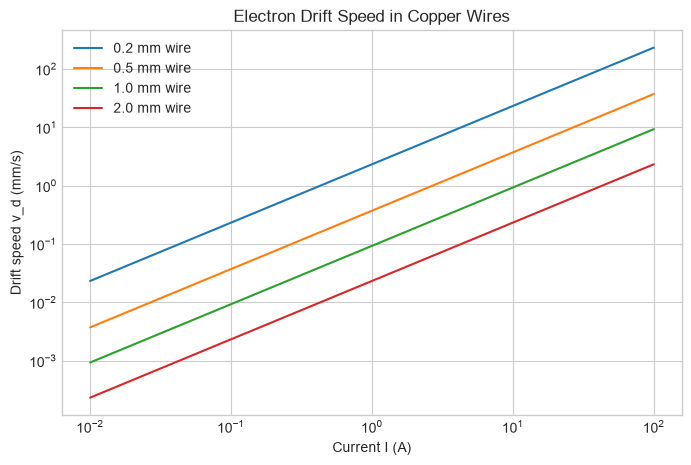

In [3]:
# Plot: drift speed versus current for different wire diameters
currents = np.logspace(-2, 2, 200)  # 0.01 A to 100 A
diameters_mm = [0.2, 0.5, 1.0, 2.0]

fig, ax = plt.subplots(figsize=(8, 5))
for d in diameters_mm:
    v = drift_speed(currents, d)
    ax.loglog(currents, v * 1e3, label=f'{d} mm wire')  # mm/s

ax.set_title('Electron Drift Speed in Copper Wires')
ax.set_xlabel('Current I (A)')
ax.set_ylabel('Drift speed v_d (mm/s)')
ax.legend()
plt.show()

## Simulation 1: Fast Random Motion + Tiny Net Drift

Electrons in a metal move randomly at high microscopic speeds due to thermal energy.
When an electric field is applied, there is only a tiny directional bias, creating a slow net drift.

In the simulation below, each particle takes many left/right steps. The individual motion is fast and zig-zag, but the **average position** drifts slowly.

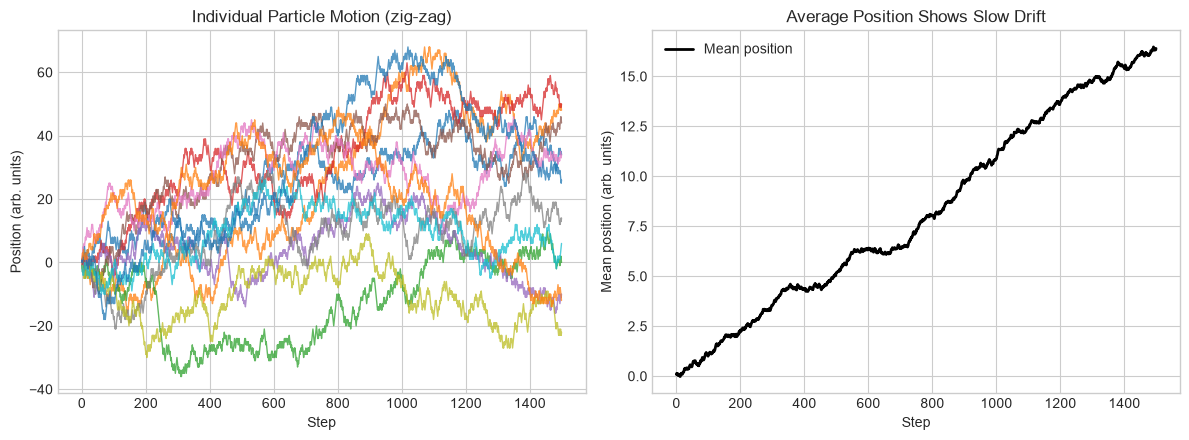

Net drift per step = 0.0100 position-units/step
Each step is large and random, but net drift is only a small leftover bias.


In [4]:
# Biased random walk (conceptual, not exact physical scale)
num_particles = 500
num_steps = 1500
step_size = 1.0
p_right = 0.505  # slight bias due to electric field

steps = np.where(np.random.rand(num_particles, num_steps) < p_right, 1, -1)
x = np.cumsum(steps * step_size, axis=1)
mean_x = x.mean(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# A few sample trajectories
for i in range(12):
    axes[0].plot(x[i], alpha=0.75, linewidth=1)
axes[0].set_title('Individual Particle Motion (zig-zag)')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Position (arb. units)')

# Ensemble average
axes[1].plot(mean_x, color='black', linewidth=2, label='Mean position')
axes[1].set_title('Average Position Shows Slow Drift')
axes[1].set_xlabel('Step')
axes[1].set_ylabel('Mean position (arb. units)')
axes[1].legend()

plt.tight_layout()
plt.show()

net_drift_per_step = (2 * p_right - 1) * step_size
print(f'Net drift per step = {net_drift_per_step:.4f} position-units/step')
print('Each step is large and random, but net drift is only a small leftover bias.')

## Simulation 2: Signal Speed vs Electron Drift Speed

A switch can light a lamp quickly not because one electron travels from battery to lamp quickly,
but because the electromagnetic signal (electric field change) propagates through the circuit rapidly.

Typical orders of magnitude:
- Signal in wire: around $10^8$ to $2\times10^8\,\mathrm{m/s}$
- Electron drift: often around $10^{-4}$ to $10^{-3}\,\mathrm{m/s}$

Signal time for 1 m:   5.000e-09 s  (5.00 ns)
Electron drift time:   5.347e+03 s  (89.12 min)


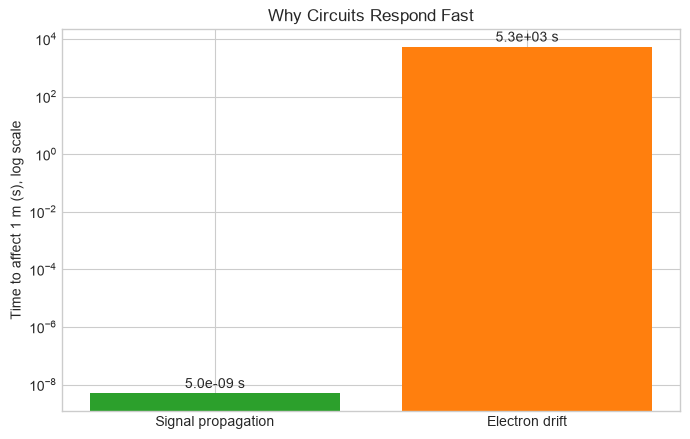

In [5]:
# Compare travel times over a 1 meter wire
L = 1.0              # meters
v_signal = 2.0e8     # m/s (order-of-magnitude in wire)
v_d = drift_speed(I_amp=2.0, diameter_mm=1.0)

t_signal = L / v_signal
t_drift = L / v_d

print(f'Signal time for 1 m:   {t_signal:.3e} s  ({t_signal*1e9:.2f} ns)')
print(f'Electron drift time:   {t_drift:.3e} s  ({t_drift/60:.2f} min)')

# Visual comparison on a log-time axis
labels = ['Signal propagation', 'Electron drift']
times = [t_signal, t_drift]
colors = ['tab:green', 'tab:orange']

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(labels, times, color=colors)
ax.set_yscale('log')
ax.set_ylabel('Time to affect 1 m (s), log scale')
ax.set_title('Why Circuits Respond Fast')

for b, t in zip(bars, times):
    ax.text(b.get_x() + b.get_width()/2, t*1.2, f'{t:.1e} s', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

In [6]:
# Optional exploration tool for students
def explore_wire(I_amp=1.0, diameter_mm=1.0, length_m=1.0, signal_speed=2.0e8):
    v = drift_speed(I_amp, diameter_mm)
    ts = length_m / signal_speed
    td = length_m / v
    ratio = td / ts
    print(f'Current: {I_amp} A, diameter: {diameter_mm} mm, length: {length_m} m')
    print(f'Drift speed: {v:.3e} m/s')
    print(f'Signal time: {ts:.3e} s')
    print(f'Drift time:  {td:.3e} s')
    print(f'Drift is about {ratio:.3e} times slower than signal propagation.')

# Try a few classroom examples
explore_wire(I_amp=0.5, diameter_mm=0.5, length_m=2.0)
print()
explore_wire(I_amp=5.0, diameter_mm=1.5, length_m=5.0)

Current: 0.5 A, diameter: 0.5 mm, length: 2.0 m
Drift speed: 1.870e-04 m/s
Signal time: 1.000e-08 s
Drift time:  1.069e+04 s
Drift is about 1.069e+12 times slower than signal propagation.

Current: 5.0 A, diameter: 1.5 mm, length: 5.0 m
Drift speed: 2.078e-04 m/s
Signal time: 2.500e-08 s
Drift time:  2.406e+04 s
Drift is about 9.625e+11 times slower than signal propagation.


In [1]:
kjh okj
pkh;kj
hkjgl

SyntaxError: invalid syntax (2053376349.py, line 1)

## Takeaway for Electronics

- Electrons are already present everywhere in the wire.
- When a source is connected, the electric field establishes quickly throughout the circuit.
- That field causes a tiny net drift of electrons, which carries current.
- So fast circuit response comes from **field/signal propagation**, not fast end-to-end electron travel.

## 3D VPython Demo (Interactive)

This simulation makes the contrast visual:
- Particles move rapidly and randomly (thermal-like motion).
- A small bias to the +x direction creates slow net drift.

Adjust the sliders while it runs:
- `Drift bias`: average push to the right.
- `Random kick`: strength of random motion.
- `Damping`: how quickly velocity memory decays.
- `dt`: simulation timestep.

If `vpython` is not installed in this kernel, run:

```python
%pip install vpython
```

In [ ]:
import random
import sys
import subprocess
import importlib
import numpy as np


def ensure_package(pip_name, import_name=None):
    """Ensure a package is importable in the current kernel environment."""
    module_name = import_name or pip_name
    try:
        importlib.import_module(module_name)
        return False
    except Exception:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", pip_name])
        importlib.invalidate_caches()
        importlib.import_module(module_name)
        return True


installed_any = False
installed_any |= ensure_package("setuptools", "pkg_resources")
installed_any |= ensure_package("vpython", "vpython")

if installed_any:
    print("Installed missing dependencies. If VPython still fails to render, restart the kernel and run this cell again.")

from vpython import canvas, vector, color, sphere, cylinder, arrow, rate, slider, wtext

# ---------- Scene ----------
scene = canvas(
    title='Electron Motion in a Wire: Fast Random Motion + Slow Drift',
    width=980,
    height=560,
    background=vector(0.06, 0.07, 0.10)
)
scene.forward = vector(-1, -0.2, -0.6)
scene.range = 7

wire_length = 10.0
wire_radius = 1.2

wire = cylinder(
    pos=vector(-wire_length / 2, 0, 0),
    axis=vector(wire_length, 0, 0),
    radius=wire_radius,
    color=vector(0.45, 0.52, 0.65),
    opacity=0.25
)

# Drift direction indicator
drift_arrow = arrow(
    pos=vector(-wire_length / 2 - 1.5, wire_radius + 0.9, 0),
    axis=vector(2.2, 0, 0),
    shaftwidth=0.16,
    color=color.orange
)

# ---------- Controls ----------
scene.append_to_caption('\nControls:\n')
scene.append_to_caption('Drift bias   ')
drift_s = slider(min=0.000, max=0.040, value=0.010, step=0.001)
scene.append_to_caption('\nRandom kick  ')
rand_s = slider(min=0.010, max=0.200, value=0.080, step=0.005)
scene.append_to_caption('\nDamping      ')
damp_s = slider(min=0.85, max=0.999, value=0.96, step=0.001)
scene.append_to_caption('\ndt           ')
dt_s = slider(min=0.01, max=0.12, value=0.04, step=0.005)
scene.append_to_caption('\n\n')
status = wtext(text='')

# ---------- Particles ----------
N = 120
radius_e = 0.075

particles = []
vel = []
for _ in range(N):
    # Uniform in wire cross-section
    r = wire_radius * np.sqrt(random.random())
    th = 2 * np.pi * random.random()
    y = r * np.cos(th)
    z = r * np.sin(th)
    x = random.uniform(-wire_length / 2, wire_length / 2)

    p = sphere(
        pos=vector(x, y, z),
        radius=radius_e,
        color=vector(0.3, 0.8, 1.0),
        shininess=0.2,
        make_trail=False
    )
    particles.append(p)

    # Initial random velocities
    vel.append(vector(
        random.uniform(-0.2, 0.2),
        random.uniform(-0.2, 0.2),
        random.uniform(-0.2, 0.2)
    ))

# ---------- Simulation loop ----------
steps = 0
while True:
    rate(120)

    drift_bias = drift_s.value
    random_kick = rand_s.value
    damping = damp_s.value
    dt = dt_s.value

    sum_vx = 0.0

    for i, p in enumerate(particles):
        # Random thermal-like agitation + tiny rightward bias
        kick = vector(
            random.uniform(-random_kick, random_kick),
            random.uniform(-random_kick, random_kick),
            random.uniform(-random_kick, random_kick)
        )

        vel[i] = damping * vel[i] + kick + vector(drift_bias, 0, 0)
        p.pos += vel[i] * dt

        # Periodic wrap in x (like a long wire segment)
        if p.pos.x > wire_length / 2:
            p.pos.x -= wire_length
        elif p.pos.x < -wire_length / 2:
            p.pos.x += wire_length

        # Reflective boundaries in y,z to stay in wire
        rho = np.sqrt(p.pos.y**2 + p.pos.z**2)
        if rho > (wire_radius - radius_e):
            # Push back to boundary surface
            scale = (wire_radius - radius_e) / rho
            p.pos.y *= scale
            p.pos.z *= scale

            # Reflect radial component of velocity
            normal = vector(0, p.pos.y, p.pos.z)
            if normal.mag > 0:
                normal = normal.norm()
                vel[i] = vel[i] - 2 * vel[i].dot(normal) * normal

        sum_vx += vel[i].x

    mean_vx = sum_vx / N
    drift_arrow.axis = vector(2.0 + 80 * mean_vx, 0, 0)

    if steps % 10 == 0:
        status.text = (
            f"Mean vx: {mean_vx:+.4f}  |  "
            f"drift_bias={drift_bias:.3f}, random_kick={random_kick:.3f}, damping={damping:.3f}, dt={dt:.3f}"
        )

    steps += 1

ImportError: vpython is not installed. Run `%pip install vpython` in this notebook, then rerun this cell.

In [ ]:
# Quick check before running the full VPython animation cell
import pkg_resources
import vpython
print('Dependency check passed: pkg_resources and vpython are available.')